# Connect Python to SQL Server 

In [1]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(
    r"DRIVER={SQL Server};"
    r"SERVER=localhost\SQLEXPRESS;"     
    r"DATABASE=DataCleaningDB;" 
    r"Trusted_Connection=yes;"  
)

engine = create_engine("mssql+pyodbc:///?odbc_connect=%s" % params)
try:
    with engine.connect() as conn:
        print("Connected successfully to SQL Server.")
except Exception as e:
    print("Connection failed:", e)

Connected successfully to SQL Server.


In [2]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT name FROM sys.databases"))
    print("Databases:")
    for row in result:
        print("-", row.name)


Databases:
- master
- tempdb
- model
- msdb
- MyDatabase
- SalesDB
- AdventureWorksDW2022
- DataCleaningDB


In [3]:
import pandas as pd

with engine.connect() as conn:
    query = text("""
        SELECT TABLE_NAME 
        FROM INFORMATION_SCHEMA.TABLES 
        WHERE TABLE_TYPE='BASE TABLE'
    """)
    result = conn.execute(query)
    tables = [row[0] for row in result]
    print("Tables in DataCleaningDB:", tables)


Tables in DataCleaningDB: ['raw_employees', 'cleaned_employees', 'anomaly_employees', 'cleaning_log']


In [4]:
print(engine.url)               
with engine.connect() as conn:
    print(conn.execute(text("SELECT DB_NAME()")).scalar())   


mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BSQL+Server%7D%3BSERVER%3Dlocalhost%5CSQLEXPRESS%3BDATABASE%3DDataCleaningDB%3BTrusted_Connection%3Dyes%3B
DataCleaningDB


In [5]:
import pyodbc

data = [
    ["E101", "Alice", 29, "IT", "50000", "2021-02-20"],
    ["E102", "BOB", "thirty", "Finance", "sixty thousand", "2020/13/01"],
    ["E103", None, 45, "HR", "70000", "2019-11-11"],
    ["E104", "Charlie", None, "Marketing", "80000", "N/A"],
    ["E105", "david", 35, "Sales", None, "2022-06-15"],
    ["A12", "John Smith", None, "HR", "50000", "2020-01-15"],
    ["A12", "john smith", None, "hr", "fifty thousand", "2020/01/15"],
    ["B09", "Jane Doe", None, "Finance", "60000", "2019-05-20"],
    ["C77", None, None, "Finance", "70000", "invalid_date"],
    [None, "Chris Lee", None, "Finance", "70000.0", "2018-09-10"],
    ["D42", "Maria Garcia", None, "HR", None, None],
    ["A12", "John Smith", None, "HR", "50000", "2020-01-15"],
    ["A12", "john smith", None, "hr", "fifty thousand", "2020/01/15"],
    ["B09", "Jane Doe", None, "Finance", "60000", "2019-05-20"],
    ["C77", None, None, "Finance", "70000", "invalid_date"],
    [None, "Chris Lee", None, "Finance", "70000.0", "2018-09-10"],
    ["D42", "Maria Garcia", None, "HR", None, None],
]

columns = ["source_id", "name", "age", "department", "salary", "joining_date"]
df_dirty = pd.DataFrame(data, columns=columns)

conn_str = (
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=localhost\SQLEXPRESS;"
    r"DATABASE=DataCleaningDB;"
    r"Trusted_Connection=yes;"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()
cursor.fast_executemany = True

insert_sql = """
INSERT INTO dbo.raw_employees (source_id, name, age, department, salary, joining_date)
VALUES (?, ?, ?, ?, ?, ?)
"""
rows = df_dirty.fillna("").astype(str).values.tolist()
cursor.executemany(insert_sql, rows)
conn.commit()
cursor.close()
conn.close()

print("Sample dirty dataset inserted successfully into dbo.raw_employees!")
display(df_dirty)


Sample dirty dataset inserted successfully into dbo.raw_employees!


,source_id,name,age,department,salary,joining_date
0,E101,Alice,29,IT,50000,2021-02-20
1,E102,BOB,thirty,Finance,sixty thousand,2020/13/01
2,E103,None,45,HR,70000,2019-11-11
3,E104,Charlie,None,Marketing,80000,N/A
4,E105,david,35,Sales,None,2022-06-15
5,A12,John Smith,None,HR,50000,2020-01-15
6,A12,john smith,None,hr,fifty thousand,2020/01/15
7,B09,Jane Doe,None,Finance,60000,2019-05-20
8,C77,None,None,Finance,70000,invalid_date
9,None,Chris Lee,None,Finance,70000.0,2018-09-10


In [6]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sqlalchemy import text, create_engine, NVARCHAR, Float, Integer, DateTime
import urllib
import time
from datetime import datetime

# Rebuild engine with safe settings (avoids HY104)
connection_string = (
    r"Driver={ODBC Driver 17 for SQL Server};"
    r"Server=localhost\SQLEXPRESS;"
    r"Database=DataCleaningDB;"
    r"Trusted_Connection=yes;"
    r"Encrypt=no;"
)
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    connect_args={"autocommit": True},
    fast_executemany=True,  
    isolation_level="AUTOCOMMIT"
)

df = pd.read_sql(text("SELECT * FROM raw_employees"), engine)
print("Raw data loaded successfully!")
display(df.head())

# Initialize timed log
timed_log = []

def log_step(step_desc, start_time):
    timed_log.append({
        "step_number": len(timed_log) + 1,
        "description": step_desc,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "duration_sec": round(time.time() - start_time, 2)
    })

# CLEANING STEPS 

# Step 1: Standardize column names
start = time.time()
df.columns = df.columns.str.strip().str.lower()
log_step("Standardized column names to lowercase.", start)

# Step 2: Trim whitespace
start = time.time()
for col in ["source_id", "name", "age", "department", "salary", "joining_date"]:
    df[col] = df[col].astype(str).str.strip()
log_step("Trimmed whitespace from text fields.", start)

# Step 3: Replace invalid or empty values
start = time.time()
for col in ["source_id", "name", "department", "salary", "joining_date"]:
    df[col] = df[col].replace(
        ["None", "nan", "NaN", "", "invalid_date", "N/A"], np.nan
    )
log_step("Replaced invalid or empty entries with NaN.", start)

# Step 4: Capitalize text fields
start = time.time()
df["name"] = df["name"].str.title()
df["department"] = df["department"].str.title()
log_step("Standardized capitalization in name and department.", start)

# Step 5: Convert salary text to numbers
start = time.time()
def convert_salary(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().replace(",", "").replace("$", "")
    words_to_numbers = {
        "fifty thousand": 50000,
        "sixty thousand": 60000,
        "seventy thousand": 70000,
        "eighty thousand": 80000
    }
    return words_to_numbers.get(val, float(val)) if val.replace('.', '', 1).isdigit() else words_to_numbers.get(val, np.nan)

df["salary"] = df["salary"].apply(convert_salary)
log_step("Converted salary text to numeric values.", start)

# Step 6: Parse joining dates
start = time.time()
df["joining_date"] = pd.to_datetime(df["joining_date"], errors="coerce")
log_step("Parsed valid joining dates; set invalid to NaT.", start)

# Step 7: Clean age values
start = time.time()
def clean_age(val):
    try:
        val = int(val)
        return val if val > 0 else np.nan
    except:
        return np.nan
df["age"] = df["age"].apply(clean_age)
log_step("Validated and cleaned age column.", start)

# Step 8: Remove duplicates
start = time.time()
before = len(df)
df.drop_duplicates(subset=["source_id", "name", "joining_date"], inplace=True)
after = len(df)
log_step(f"Removed {before - after} duplicate records.", start)

# Step 9: Fill missing departments
start = time.time()
df["department"] = df["department"].fillna("Unassigned")
log_step("Filled missing departments with 'Unassigned'.", start)

start = time.time()

# Define rule-based anomalies
df["rule_anomaly"] = (
    (df["age"] < 18) | 
    (df["age"] > 65) | 
    (df["salary"] < 10000) | 
    (df["salary"] > 200000)
)

rule_anomalies = df["rule_anomaly"].sum()
log_step(f"Flagged {rule_anomalies} rule-based anomalies.", start)

# ML-BASED ANOMALY DETECTION (Isolation Forest)
start = time.time()

# Prepare numeric features for anomaly detection
ml_df = df[["age", "salary"]].copy().fillna(0)

# Fit Isolation Forest model
iso = IsolationForest(contamination=0.1, random_state=42)
df["ml_anomaly"] = iso.fit_predict(ml_df)

# Map: -1 = anomaly, 1 = normal
df["ml_anomaly"] = df["ml_anomaly"].apply(lambda x: True if x == -1 else False)

ml_anomalies = df["ml_anomaly"].sum()
log_step(f"Detected {ml_anomalies} ML-based anomalies using IsolationForest.", start)

# COMBINE BOTH
df["is_anomaly"] = df["rule_anomaly"] | df["ml_anomaly"]
df.drop(columns=["rule_anomaly", "ml_anomaly"], inplace=True)

# Count total anomalies
total_anomalies = df["is_anomaly"].sum()
log_step(f"Final anomaly flag column added. Total anomalies = {total_anomalies}.", time.time())

print(f"Total anomalies flagged: {total_anomalies}")
display(df[df['is_anomaly'] == True])

# LOG CREATION 

timed_log_df = pd.DataFrame(timed_log)
display(df.head())
display(timed_log_df)

# Convert the timed log into a DataFrame for saving
log_df = pd.DataFrame(timed_log)

# Ensure column order
log_df = log_df[["step_number", "description", "timestamp", "duration_sec"]]


# Explicit dtype mapping
dtype_cleaned = {
    "source_id": NVARCHAR(50),
    "name": NVARCHAR(100),
    "age": Float,
    "department": NVARCHAR(50),
    "salary": Float,
    "joining_date": DateTime,
}

dtype_log = {
    "step_number": Integer,
    "description": NVARCHAR(255),
    "timestamp": NVARCHAR(50),
    "duration_sec": Float,
}

dtype_anomaly = {
    "source_id": NVARCHAR(50),
    "name": NVARCHAR(100),
    "age": Float,
    "department": NVARCHAR(50),
    "salary": Float,
    "joining_date": DateTime,
    "is_anomaly": Integer
}

# Manually drop tables to bypass introspection issue
with engine.begin() as conn:
    conn.exec_driver_sql("IF OBJECT_ID('cleaned_employees', 'U') IS NOT NULL DROP TABLE cleaned_employees;")
    conn.exec_driver_sql("IF OBJECT_ID('cleaning_log', 'U') IS NOT NULL DROP TABLE cleaning_log;")
    conn.exec_driver_sql("IF OBJECT_ID('anomaly_employees', 'U') IS NOT NULL DROP TABLE anomaly_employees;")

df.to_sql(
    "cleaned_employees",
    con=engine,
    if_exists="replace",
    index=False,
    dtype=dtype_cleaned,
    method=None,
)

df.to_sql(
    "anomaly_employees",
    con=engine,
    if_exists="replace",
    index=False,
    dtype=dtype_anomaly
)

log_df.to_sql(
    "cleaning_log",
    con=engine,
    if_exists="replace",
    index=False,
    dtype=dtype_log,
    method=None,
)
log_step("Saved anomaly-detected dataset to SQL Server.", time.time())
print("Anomaly detection results saved to SQL as 'anomaly_employees'.")
print("Cleaned tables successfully written to SQL Server!")


Raw data loaded successfully!


,source_id,name,age,department,salary,joining_date
0,E101,Alice,29,IT,50000,2021-02-20
1,E102,BOB,thirty,Finance,sixty thousand,2020/13/01
2,E103,,45,HR,70000,2019-11-11
3,E104,Charlie,,Marketing,80000,N/A
4,E105,david,35,Sales,,2022-06-15


Total anomalies flagged: 1


,source_id,name,age,department,salary,joining_date,is_anomaly
4,E105,David,35.0,Sales,NaN,2022-06-15,True


,source_id,name,age,department,salary,joining_date,is_anomaly
0,E101,Alice,29.0,It,50000.0,2021-02-20,False
1,E102,Bob,NaN,Finance,60000.0,NaT,False
2,E103,NaN,45.0,Hr,70000.0,2019-11-11,False
3,E104,Charlie,NaN,Marketing,80000.0,NaT,False
4,E105,David,35.0,Sales,NaN,2022-06-15,True


,step_number,description,timestamp,duration_sec
0,1,Standardized column names to lowercase.,2025-11-09 22:29:01,0.00
1,2,Trimmed whitespace from text fields.,2025-11-09 22:29:01,0.00
2,3,Replaced invalid or empty entries with NaN.,2025-11-09 22:29:01,0.00
3,4,Standardized capitalization in name and depart...,2025-11-09 22:29:01,0.00
4,5,Converted salary text to numeric values.,2025-11-09 22:29:01,0.00
5,6,Parsed valid joining dates; set invalid to NaT.,2025-11-09 22:29:01,0.00
6,7,Validated and cleaned age column.,2025-11-09 22:29:01,0.00
7,8,Removed 40 duplicate records.,2025-11-09 22:29:01,0.01
8,9,Filled missing departments with 'Unassigned'.,2025-11-09 22:29:01,0.00
9,10,Flagged 0 rule-based anomalies.,2025-11-09 22:29:01,0.00


Anomaly detection results saved to SQL as 'anomaly_employees'.
Cleaned tables successfully written to SQL Server!


# Generate Cleaned Data and Log Reports in Excel

In [23]:
from pathlib import Path

# Export both tables to Excel with formatting
output_path = Path(r"G:\.VIT\Courses\DBMS\DBMS_PROJECT\DataCleaningReports.xlsx")

# Re-fetch from SQL to ensure final version
cleaned_df = pd.read_sql(text("SELECT * FROM cleaned_employees"), engine)
log_df = pd.read_sql(text("SELECT * FROM cleaning_log"), engine)

with pd.ExcelWriter(output_path, engine="xlsxwriter", datetime_format="yyyy-mm-dd", date_format="yyyy-mm-dd") as writer:
    # Write both sheets
    cleaned_df.to_excel(writer, sheet_name="Cleaned Employees", index=False)
    log_df.to_excel(writer, sheet_name="Cleaning Log", index=False)

    # Autofit column widths
    for sheet_name, df in {"Cleaned Employees": cleaned_df, "Cleaning Log": log_df}.items():
        worksheet = writer.sheets[sheet_name]
        for i, col in enumerate(df.columns):
            # Compute column width (minimum 12)
            col_width = max(df[col].astype(str).map(len).max(), len(col)) + 2
            worksheet.set_column(i, i, min(col_width, 40))
    
    # Header formatting
    header_format = writer.book.add_format({
        "bold": True, "bg_color": "#D9EAD3", "border": 1, "align": "center"
    })
    for sheet in writer.sheets.values():
        sheet.set_row(0, None, header_format)

print(f"Excel report generated successfully: {output_path.resolve()}")


Excel report generated successfully: G:\.VIT\Courses\DBMS\DBMS_PROJECT\DataCleaningReports.xlsx


In [32]:
from sqlalchemy import create_engine, text, inspect

server = r"Prathish-01\SQLEXPRESS"   
database = "DBMS_Proj"             

connection_string = (
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

# Create SQLAlchemy engine
engine = create_engine(connection_string)
print("Connected to SQL Server using Windows Authentication!")


Connected to SQL Server using Windows Authentication!


Dataset loaded successfully! Shape: (151445, 11)


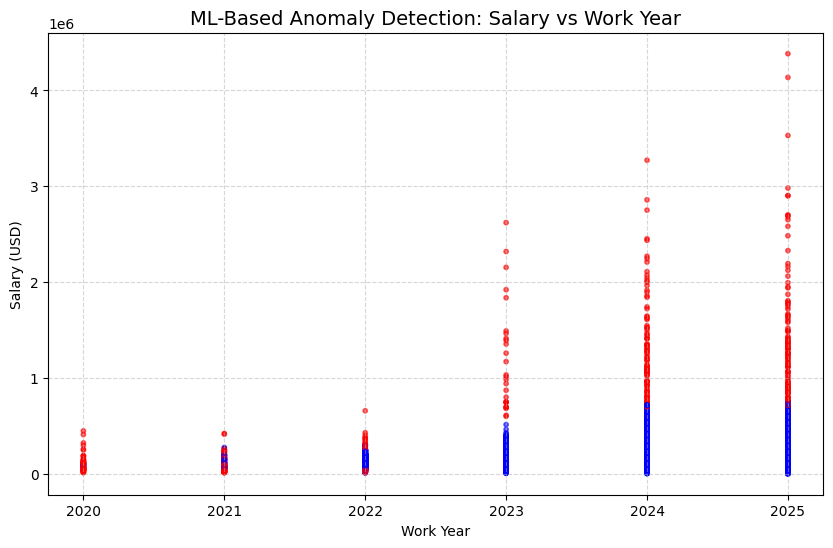

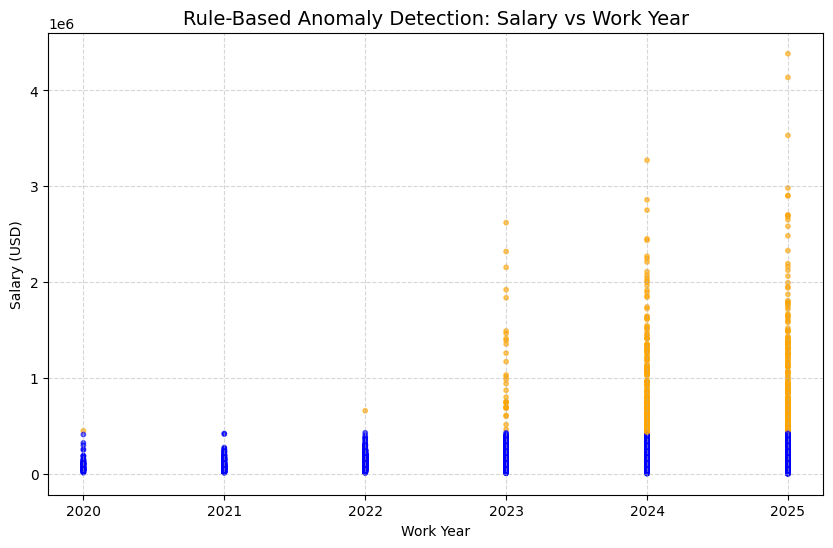


ANOMALY SUMMARY
Rule-based anomalies detected: 1077
ML-based anomalies detected: 729
Anomalies flagged by BOTH methods: 332


,step_number,description,timestamp,duration_sec
0,1,Standardized column names to lowercase.,2025-11-09 23:38:14,0.00
1,2,Trimmed whitespace from string columns.,2025-11-09 23:38:15,0.42
2,3,Replaced invalid placeholders with NaN.,2025-11-09 23:38:15,0.63
3,4,Filled missing company_size with 'Unknown'.,2025-11-09 23:38:15,0.00
4,5,Converted salary_in_usd to numeric.,2025-11-09 23:38:15,0.00
5,6,Injected 757 synthetic anomalies.,2025-11-09 23:38:15,0.04
6,7,Detected 1077 anomalies using rule-based (3σ) ...,2025-11-09 23:38:15,0.01
7,8,Detected 729 anomalies using ML-based Isolatio...,2025-11-09 23:38:19,3.54



Processing complete!
Rule-based anomalies: 1077
ML-based anomalies: 729
Cleaned data with anomalies saved to 'salaries_cleaned' table in SQL Server.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import time
from datetime import datetime
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# LOAD DATA
df = pd.read_sql("SELECT * FROM salaries", con=engine)
print(f"Dataset loaded successfully! Shape: {df.shape}")

# Initialize cleaning and timing logs
cleaning_log = []
timed_log = []

def log_step(desc, start_time):
    timed_log.append({
        "step_number": len(timed_log)+1,
        "description": desc,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "duration_sec": round(time.time() - start_time, 2)
    })

# DATA CLEANING

# Step 1: Standardize column names
start = time.time()
df.columns = df.columns.str.strip().str.lower()
log_step("Standardized column names to lowercase.", start)

# Step 2: Trim whitespace for object columns
start = time.time()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
log_step("Trimmed whitespace from string columns.", start)

# Step 3: Replace invalid values
start = time.time()
df.replace(["None", "nan", "NaN", "", "N/A"], np.nan, inplace=True)
log_step("Replaced invalid placeholders with NaN.", start)

# Step 4: Fill missing company_size with 'Unknown'
start = time.time()
df["company_size"] = df["company_size"].fillna("Unknown")
log_step("Filled missing company_size with 'Unknown'.", start)

# Step 5: Convert salary_in_usd to numeric
start = time.time()
df["salary_in_usd"] = pd.to_numeric(df["salary_in_usd"], errors="coerce")
log_step("Converted salary_in_usd to numeric.", start)

# SYNTHETIC ANOMALY INJECTION

start = time.time()
np.random.seed(42)
num_anomalies = int(0.005 * len(df))  # Inject 0.5% anomalies
anomaly_indices = np.random.choice(df.index, num_anomalies, replace=False)

# Split indices evenly between high and low anomalies
half = num_anomalies // 2
high_idx = anomaly_indices[:half]
low_idx = anomaly_indices[half:]

# Ensure both sides exist
if len(high_idx) > 0:
    df.loc[high_idx, "salary_in_usd"] *= np.random.uniform(3, 10, size=len(high_idx))
if len(low_idx) > 0:
    df.loc[low_idx, "salary_in_usd"] /= np.random.uniform(3, 10, size=len(low_idx))

log_step(f"Injected {num_anomalies} synthetic anomalies.", start)

# RULE-BASED ANOMALY DETECTION

start = time.time()
salary_mean = df["salary_in_usd"].mean()
salary_std = df["salary_in_usd"].std()
df["rule_anomaly"] = (np.abs(df["salary_in_usd"] - salary_mean) > 3 * salary_std)
num_rule = df["rule_anomaly"].sum()
log_step(f"Detected {num_rule} anomalies using rule-based (3σ) method.", start)

# ML-BASED ANOMALY DETECTION (Isolation Forest)

start = time.time()
numeric_cols = ["salary_in_usd", "work_year", "remote_ratio"]
df_numeric = df[numeric_cols].copy().dropna()

iso = IsolationForest(
    contamination=0.005,   # roughly 0.5% anomalies
    n_estimators=200,
    random_state=42
)
df.loc[df_numeric.index, "ml_anomaly"] = iso.fit_predict(df_numeric)
df["ml_anomaly"] = df["ml_anomaly"].map({1: False, -1: True})
num_ml = df["ml_anomaly"].sum()
log_step(f"Detected {num_ml} anomalies using ML-based Isolation Forest.", start)

# VISUALIZATION (MATPLOTLIB)

plt.figure(figsize=(10,6))
plt.scatter(
    df["work_year"], df["salary_in_usd"],
    c=df["ml_anomaly"].map({True: "red", False: "blue"}),
    s=10, alpha=0.6
)
plt.title("ML-Based Anomaly Detection: Salary vs Work Year", fontsize=14)
plt.xlabel("Work Year")
plt.ylabel("Salary (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(
    df["work_year"], df["salary_in_usd"],
    c=df["rule_anomaly"].map({True: "orange", False: "blue"}),
    s=10, alpha=0.6
)
plt.title("Rule-Based Anomaly Detection: Salary vs Work Year", fontsize=14)
plt.xlabel("Work Year")
plt.ylabel("Salary (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# COUNT ANOMALIES
num_rule = df["rule_anomaly"].sum()
num_ml = df["ml_anomaly"].sum()
num_both = ((df["rule_anomaly"]) & (df["ml_anomaly"])).sum()

print("\nANOMALY SUMMARY")
print(f"Rule-based anomalies detected: {num_rule}")
print(f"ML-based anomalies detected: {num_ml}")
print(f"Anomalies flagged by BOTH methods: {num_both}")

# LOG OUTPUT

timed_log_df = pd.DataFrame(timed_log)
display(timed_log_df)

print("\nProcessing complete!")
print(f"Rule-based anomalies: {num_rule}")
print(f"ML-based anomalies: {num_ml}")

df.to_sql("salaries_cleaned", con=engine, if_exists="replace", index=False)
print("Cleaned data with anomalies saved to 'salaries_cleaned' table in SQL Server.")